# Customer Churn Prediction
## Final Lab Project — Logistic Regression
Members:
Assil Sabbagh (202402688)
Cynthia Issa (202400728)
---

## 1 - Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

%matplotlib inline

print('Packages loaded successfully!')

Packages loaded successfully!


## 2 - Overview of the Problem

**Problem Statement**: Given a real telecom dataset containing customer information.
- A training set of customer records labeled as **Churn (y=1)** or **No Churn (y=0)**
- A test set of customer records with the same labels
- Each customer is described by features such as tenure, monthly charges, contract type, etc.

### 2.1 - Load the Dataset

In [3]:
# Load the dataset
df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded successfully!
Shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.2 - Data Quality Report

In [4]:
print('='*50)
print('DATA QUALITY REPORT')
print('='*50)

print(f'\nTotal Rows    : {df.shape[0]}')
print(f'Total Columns : {df.shape[1]}')

print('\n--- Column Data Types ---')
print(df.dtypes)

print('\n--- Missing Values per Column ---')
print(df.isnull().sum())
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')

print('\n--- Basic Statistics (Numerical Columns) ---')
print(df.describe())

print('\n--- Target Variable Distribution ---')
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {round(df['Churn'].value_counts(normalize=True)['Yes']*100, 2)}%")

DATA QUALITY REPORT

Total Rows    : 7043
Total Columns : 21

--- Column Data Types ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

--- Missing Values per Column ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport

### 2.3 - Data Cleaning and Preprocessing

In [5]:
# Drop customerID — not useful for prediction
df = df.drop(columns=['customerID'])

# TotalCharges has blank spaces ' ' for new customers with tenure=0
# Step 1: replace spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
# Step 2: convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Step 3: fill NaN with median
median_val = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_val)

# Encode target variable: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all remaining categorical columns using LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Safety net: drop any remaining rows with NaN
df = df.dropna()

# Convert all columns to float
df = df.astype(float)

# Final check
print(f'Remaining NaN values: {df.isnull().sum().sum()}')
print(f'Data cleaning complete! Shape: {df.shape}')
df.head()

Remaining NaN values: 0
Data cleaning complete! Shape: (7043, 20)


C:\Users\User\AppData\Local\Temp\ipykernel_21136\2742121518.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.85,29.85,0.0
1,1.0,0.0,0.0,0.0,34.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,56.95,1889.50,0.0
2,1.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,53.85,108.15,1.0
3,1.0,0.0,0.0,0.0,45.0,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,42.30,1840.75,0.0
4,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,70.70,151.65,1.0


### 2.4 - Prepare and Reshape Data

We reshaped images into flat vectors, here we prepare our feature matrix X and target vector y, then reshape them to fit the model.


In [6]:
# Separate features and target
X_raw = df.drop(columns=['Churn']).values   # shape: (m, n_features)
y_raw = df['Churn'].values                  # shape: (m,)

# Split into training (80%) and test (20%) sets
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Standardize features 
scaler = StandardScaler()
X_train_raw = scaler.fit_transform(X_train_raw)
X_test_raw  = scaler.transform(X_test_raw)

train_set_x = X_train_raw.T   # shape: (n_features, m_train)
test_set_x  = X_test_raw.T    # shape: (n_features, m_test)

# Labels need shape (1, m)
train_set_y = y_train_raw.reshape(1, -1)   # shape: (1, m_train)
test_set_y  = y_test_raw.reshape(1, -1)    # shape: (1, m_test)

m_train     = train_set_x.shape[1]
m_test      = test_set_x.shape[1]
n_features  = train_set_x.shape[0]

print(f'Number of training examples : m_train = {m_train}')
print(f'Number of test examples     : m_test  = {m_test}')
print(f'Number of features          : n_x     = {n_features}')
print(f'train_set_x shape: {train_set_x.shape}')
print(f'train_set_y shape: {train_set_y.shape}')
print(f'test_set_x  shape: {test_set_x.shape}')
print(f'test_set_y  shape: {test_set_y.shape}')

Number of training examples : m_train = 5634
Number of test examples     : m_test  = 1409
Number of features          : n_x     = 19
train_set_x shape: (19, 5634)
train_set_y shape: (1, 5634)
test_set_x  shape: (19, 1409)
test_set_y  shape: (1, 1409)


## 3 - General Architecture of the Learning Algorithm

We build a **Logistic Regression** model using a Neural Network mindset.

**Mathematical expression of the algorithm:**

For one example $x^{(i)}$:

$$z^{(i)} = w^T x^{(i)} + b \tag{1}$$

$$\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)}) \tag{2}$$

$$\mathcal{L}(a^{(i)}, y^{(i)}) = -y^{(i)} \log(a^{(i)}) - (1 - y^{(i)}) \log(1 - a^{(i)}) \tag{3}$$

The cost is then computed by summing over all training examples:

$$J = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}(a^{(i)}, y^{(i)}) \tag{6}$$

**Key steps:**
- Initialize the parameters of the model
- Learn the parameters by minimizing the cost
- Use the learned parameters to make predictions on the test set
- Analyse the results and conclude

## 4 - Building the Parts of Our Algorithm

The main steps for building a Neural Network are:
1. Define the model structure (number of input features)
2. Initialize the model's parameters
3. Loop:
   - Calculate current loss (forward propagation)
   - Calculate current gradient (backward propagation)
   - Update parameters (gradient descent)

### 4.1 - Helper Function: Sigmoid

In [7]:
# sigmoid
def sigmoid(z):

    s = 1 / (1 + np.exp(-z))

    return s

print('sigmoid([0, 2]) = ' + str(sigmoid(np.array([0, 2]))))

sigmoid([0, 2]) = [0.5        0.88079708]


### 4.2 - Initializing Parameters

In [8]:
# initialize_with_zeros
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0

    assert(w.shape == (dim, 1))
    assert(isinstance(b, float) or isinstance(b, int))

    return w, b

dim = 2
w, b = initialize_with_zeros(dim)
print('w = ' + str(w))
print('b = ' + str(b))

w = [[0.]
 [0.]]
b = 0


### 4.3 - Forward and Backward Propagation
We Implement `propagate()` that computes the cost function and its gradient.

Forward Propagation:
- You get X
- You compute $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, \ldots, a^{(m)})$
- You calculate the cost: $J = -\frac{1}{m} \sum_{i=1}^{m} y^{(i)} \log(a^{(i)}) + (1-y^{(i)}) \log(1-a^{(i)})$

Here are the two formulas for the gradients:

$$\frac{\partial J}{\partial w} = \frac{1}{m} X(A-Y)^T \tag{7}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (a^{(i)} - y^{(i)}) \tag{8}$$

In [9]:
# propagate
def propagate(w, b, X, Y):
    
    m = X.shape[1]

    A    = sigmoid(np.dot(w.T, X) + b)                                      # compute activation
    cost = (-1/m) * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))        # compute cost
    

    dw = (1/m) * np.dot(X, (A - Y).T)
    db = (1/m) * np.sum(A - Y)


    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())

    grads = {'dw': dw, 'db': db}

    return grads, cost

# Quick test
w_test, b_test = np.array([[1.], [2.]]), 2.
X_test_prop    = np.array([[1., 2., -1.], [3., 4., -3.2]])
Y_test_prop    = np.array([[1, 0, 1]])
grads_test, cost_test = propagate(w_test, b_test, X_test_prop, Y_test_prop)
print('dw   = ' + str(grads_test['dw']))
print('db   = ' + str(grads_test['db']))
print('cost = ' + str(cost_test))

dw   = [[0.99845601]
 [2.39507239]]
db   = 0.001455578136784208
cost = 5.801545319394553


### 4.4 - Optimization

The goal is to learn $w$ and $b$ by minimizing the cost function $J$. For a parameter $\theta$, the update rule is $\theta = \theta - \alpha \, d\theta$, where $\alpha$ is the learning rate.

In [10]:
# optimize
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    
    costs = []

    for i in range(num_iterations):

        
        grads, cost = propagate(w, b, X, Y)
       

        # Retrieve derivatives from grads
        dw = grads['dw']
        db = grads['db']

        
        w = w - learning_rate * dw
        b = b - learning_rate * db
        

        # Record the costs
        if i % 100 == 0:
            costs.append(cost)

        # Print the cost every 100 training iterations
        if print_cost and i % 100 == 0:
            print('Cost after iteration %i: %f' % (i, cost))

    params = {'w': w, 'b': b}
    grads  = {'dw': dw, 'db': db}

    return params, grads, costs

# Quick test
params_test, grads_test2, costs_test = optimize(
    w_test, b_test, X_test_prop, Y_test_prop,
    num_iterations=100, learning_rate=0.009
)
print('w  = ' + str(params_test['w']))
print('b  = ' + str(params_test['b']))
print('dw = ' + str(grads_test2['dw']))
print('db = ' + str(grads_test2['db']))

w  = [[0.19033591]
 [0.12259159]]
b  = 1.9253598300845747
dw = [[0.67752042]
 [1.41625495]]
db = 0.21919450454067657


### 4.5 - Predict

To Implement `predict()`. There are two steps:
1. Calculate $\hat{Y} = A = \sigma(w^T X + b)$
2. Convert the entries of A into 0 (if activation $\leq$ 0.5) or 1 (if activation $>$ 0.5)

In [11]:
# predict
def predict(w, b, X):
    
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)

    
    A = sigmoid(np.dot(w.T, X) + b)

    for i in range(A.shape[1]):
        # Convert probabilities to actual predictions
        if A[0][i] <= 0.5:
            Y_prediction[0][i] = 0
        else:
            Y_prediction[0][i] = 1
       
    assert(Y_prediction.shape == (1, m))

    return Y_prediction

# Quick test
w_pred = np.array([[0.1124579], [0.23106775]])
b_pred = -0.3
X_pred = np.array([[1., -1.1, -3.2], [1.2, 2., 0.1]])
print('predictions = ' + str(predict(w_pred, b_pred, X_pred)))

predictions = [[1. 1. 0.]]


## 5 - Merge All Functions into a Model

In [12]:
# model
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.005, print_cost=False):
   
    w, b = initialize_with_zeros(X_train.shape[0])

    # Gradient descent
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)

    # Retrieve parameters w and b from dictionary
    w = parameters['w']
    b = parameters['b']

    # Predict on test and training sets
    Y_prediction_test  = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)


    # Print train / test accuracy
    print('train accuracy: {} %'.format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print('test accuracy:  {} %'.format(100 - np.mean(np.abs(Y_prediction_test  - Y_test))  * 100))

    d = {
        'costs'              : costs,
        'Y_prediction_test'  : Y_prediction_test,
        'Y_prediction_train' : Y_prediction_train,
        'w'                  : w,
        'b'                  : b,
        'learning_rate'      : learning_rate,
        'num_iterations'     : num_iterations
    }

    return d

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.621310
Cost after iteration 200: 0.578501
Cost after iteration 300: 0.549949
Cost after iteration 400: 0.529340
Cost after iteration 500: 0.513665
Cost after iteration 600: 0.501314
Cost after iteration 700: 0.491337
Cost after iteration 800: 0.483129
Cost after iteration 900: 0.476280
Cost after iteration 1000: 0.470499
Cost after iteration 1100: 0.465574
Cost after iteration 1200: 0.461344
Cost after iteration 1300: 0.457685
Cost after iteration 1400: 0.454501
Cost after iteration 1500: 0.451713
Cost after iteration 1600: 0.449260
Cost after iteration 1700: 0.447092
Cost after iteration 1800: 0.445165
Cost after iteration 1900: 0.443447
train accuracy: 79.46396876109335 %
test accuracy:  80.90844570617459 %


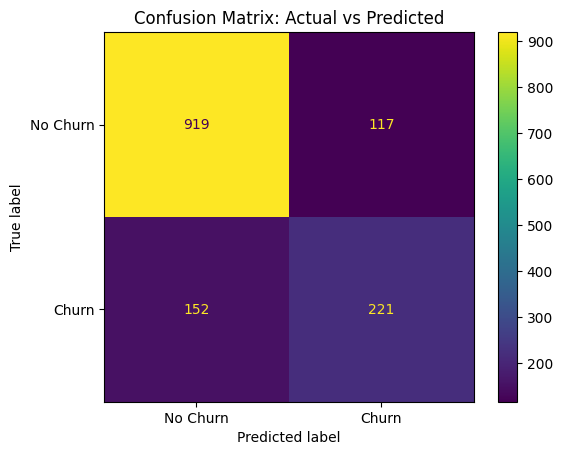

              precision    recall  f1-score   support

    No Churn       0.86      0.89      0.87      1036
       Churn       0.65      0.59      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409



In [13]:
d = model(train_set_x, train_set_y, test_set_x, test_set_y,
          num_iterations=2000, learning_rate=0.005, print_cost=True)
# Get actual and predicted values
y_actual = test_set_y.flatten()
y_predicted = d['Y_prediction_test'].flatten()

# Confusion Matrix
cm = confusion_matrix(y_actual, y_predicted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title('Confusion Matrix: Actual vs Predicted')
plt.show()

# Classification Report
print(classification_report(
    y_actual,
    y_predicted,
    target_names=['No Churn', 'Churn']
))

Training accuracy reflects how well the model fits the training data. Test accuracy shows how well it generalizes. A large gap between the two indicates **overfitting**.

## 6 - Graphs

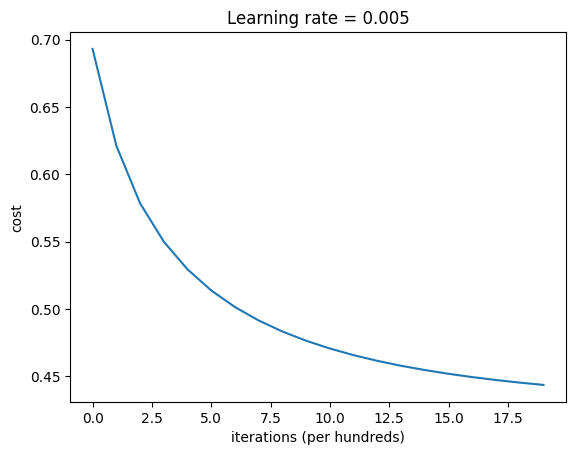

Graph 1: Cost decreases over iterations, the model is learning.


In [14]:
# Graph 1: Plot learning curve (with costs) 
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title('Learning rate = ' + str(d['learning_rate']))
plt.show()
print('Graph 1: Cost decreases over iterations, the model is learning.')

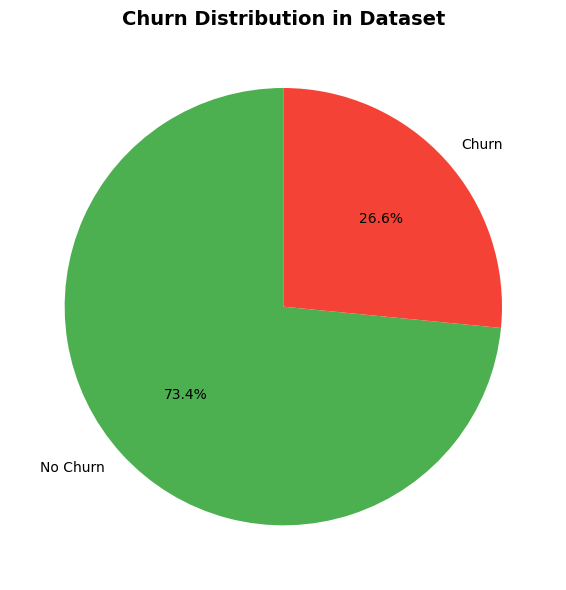

Graph 2: About 26% of customers churned.


In [15]:
# Graph 2: Churn Distribution in Dataset
churn_counts = pd.Series(train_set_y.flatten()).value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)
plt.title('Churn Distribution in Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Graph 2: About 26% of customers churned.')

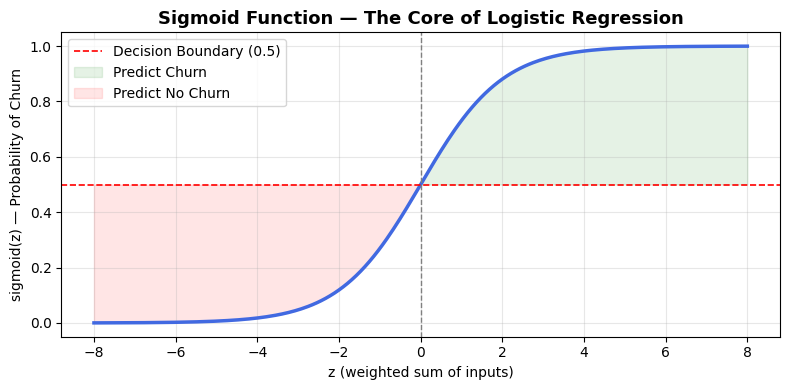

Graph 3: Sigmoid maps any input to a probability between 0 and 1.


In [16]:
# Graph 3: Sigmoid Function Visualization
z = np.linspace(-8, 8, 300)
sig = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, sig, color='royalblue', linewidth=2.5)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Decision Boundary (0.5)')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.fill_between(z, sig, 0.5, where=(sig > 0.5), alpha=0.1, color='green', label='Predict Churn')
plt.fill_between(z, sig, 0.5, where=(sig < 0.5), alpha=0.1, color='red',   label='Predict No Churn')
plt.title('Sigmoid Function — The Core of Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('z (weighted sum of inputs)')
plt.ylabel('sigmoid(z) — Probability of Churn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Graph 3: Sigmoid maps any input to a probability between 0 and 1.')

## 7 - Further Analysis



learning rate is: 0.01
train accuracy: 79.78345757898474 %
test accuracy:  80.97941802696948 %

-------------------------------------------------------

learning rate is: 0.001
train accuracy: 76.02058927937523 %
test accuracy:  77.35982966643009 %

-------------------------------------------------------

learning rate is: 0.0001
train accuracy: 73.96166134185303 %
test accuracy:  74.37899219304471 %

-------------------------------------------------------



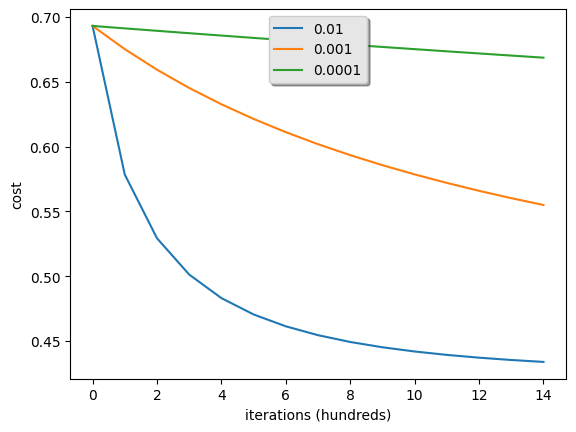

In [17]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print('learning rate is: ' + str(lr))
    models[str(lr)] = model(train_set_x, train_set_y, test_set_x, test_set_y,
                            num_iterations=1500, learning_rate=lr, print_cost=False)
    print('\n' + '-'*55 + '\n')

for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]['costs']),
             label=str(models[str(lr)]['learning_rate']))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')
legend = plt.legend(loc='upper center', shadow=True)
legend.get_frame().set_facecolor('0.90')
plt.show()

**Interpretation:**
- Different learning rates give different costs and thus different prediction results.
- If the learning rate is too large (0.01), the cost may oscillate up and down then it may even diverge.
- A lower cost doesn't always mean a better model. You must check for overfitting: it happens when training accuracy is much higher than test accuracy.

## 8 - Results Summary

**What the model achieved:**
- Trained on **80%** of ~7,000 real telecom customer records, tested on **20%**
- Predicts whether a customer will churn based on 19 features
- 
**Real-world impact:**
- Telecom companies can use this to identify at-risk customers early.
- Offer targeted discounts or better plans to retain them.
- Directly saves company revenue.
